In [9]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [10]:
torch.manual_seed(0)

In [11]:
class PINN(nn.Module):
    def __init__(self, n_hidden=4, n_neurons=20):
        super().__init__()
        layers = []
        in_dim = 2       # (z, xi)
        out_dim = 1      # x
        # Construct hidden layers
        layers.append(nn.Linear(in_dim, n_neurons))
        layers.append(nn.Tanh())
        for _ in range(n_hidden - 1):
            layers.append(nn.Linear(n_neurons, n_neurons))
            layers.append(nn.Tanh())
        # Output layer
        layers.append(nn.Linear(n_neurons, out_dim))
        self.model = nn.Sequential(*layers)

    def forward(self, z, xi):
        # z, xi have shape [N, 1]
        inp = torch.cat((z, xi), dim=1)  # shape [N, 2]
        return self.model(inp)

In [12]:
def pde_residual(net, z_in, xi_in):
    """
    Compute PDE residual: d2x/dz^2 + 2xi dx/dz + x
    """
    # Ensure gradient wrt z by requiring z_in.requires_grad_(True)
    z_in = z_in.clone().detach().requires_grad_(True)
    xi_in = xi_in.clone().detach()  # xi does not need second derivatives wrt z

    x = net(z_in, xi_in)   # shape [N, 1]
    
    # First derivative dx/dz
    dx_dz = torch.autograd.grad(
        x, z_in, 
        grad_outputs=torch.ones_like(x),
        retain_graph=True,
        create_graph=True
    )[0]  # shape [N, 1]

    # Second derivative d2x/dz^2
    d2x_dz2 = torch.autograd.grad(
        dx_dz, z_in, 
        grad_outputs=torch.ones_like(dx_dz),
        retain_graph=True,
        create_graph=True
    )[0]  # shape [N, 1]

    # PDE residual
    residual = d2x_dz2 + 2.0*xi_in*dx_dz + x
    return residual


In [13]:
def create_training_data(N_xi=10, N_z=200):
    # Sample xi in [0.1, 0.4]
    xi_vals = 0.1 + 0.3 * torch.rand(N_xi, 1)
    
    # For PDE collocation: each xi gets N_z random points in z in [0, 20]
    z_vals = 20.0 * torch.rand(N_xi*N_z, 1)
    # Repeat the xi values for each collocation point
    xi_for_colloc = xi_vals.repeat_interleave(N_z, dim=0)
    
    # For boundary conditions: we only need z=0 for each xi
    z0_vals = torch.zeros_like(xi_vals)  # shape [N_xi, 1]
    
    return xi_vals, z_vals, xi_for_colloc, z0_vals


In [14]:
# Hyperparameters
N_xi    = 100     # number of distinct damping values
N_z     = 200    # collocation points per damping value
lr      = 1e-3   # learning rate
epochs  = 4000   # training iterations

# Network
net = PINN(n_hidden=12,n_neurons=64)
optimizer = torch.optim.Adam(net.parameters(), lr=lr)

# Generate training data
xi_vals, z_vals, xi_for_colloc, z0_vals = create_training_data(N_xi, N_z)


x0 = 0.7
v0 = 1.2

for epoch in range(1, epochs+1):
    optimizer.zero_grad()
    
    # ====== PDE loss ======
    # Collocation PDE points
    res = pde_residual(net, z_vals, xi_for_colloc)
    loss_pde = torch.mean(res**2)
    
    # ====== BC loss ======
    # x(0, xi) should be 0.7
    x_bc = net(z0_vals, xi_vals)  # [N_xi, 1]
    loss_x_bc = torch.mean((x_bc - x0)**2)
    
    # dx/dz(0, xi) should be 1.2
    z0_vals_reqgrad = z0_vals.clone().detach().requires_grad_(True)
    x_bc_temp = net(z0_vals_reqgrad, xi_vals)
    dx_dz_bc = torch.autograd.grad(
        x_bc_temp, z0_vals_reqgrad,
        grad_outputs=torch.ones_like(x_bc_temp),
        retain_graph=True,
        create_graph=True
    )[0]
    loss_dx_bc = torch.mean((dx_dz_bc - v0)**2)
    
    # Total loss
    loss = loss_pde + loss_x_bc + loss_dx_bc
    loss.backward()
    optimizer.step()
    
    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6e}, PDE: {loss_pde.item():.6e}, "
              f"x(0): {loss_x_bc.item():.6e}, dx/dz(0): {loss_dx_bc.item():.6e}")


Epoch 500, Loss: 1.121766e-02, PDE: 1.110624e-02, x(0): 3.317684e-05, dx/dz(0): 7.823581e-05
Epoch 1000, Loss: 6.603580e-03, PDE: 6.512308e-03, x(0): 4.455019e-05, dx/dz(0): 4.672235e-05
Epoch 1500, Loss: 2.207908e-03, PDE: 2.173298e-03, x(0): 9.457979e-06, dx/dz(0): 2.515199e-05
Epoch 2000, Loss: 1.967412e-03, PDE: 1.940789e-03, x(0): 5.481497e-06, dx/dz(0): 2.114198e-05
Epoch 2500, Loss: 5.556358e-03, PDE: 5.447617e-03, x(0): 4.374531e-05, dx/dz(0): 6.499654e-05
Epoch 3000, Loss: 1.696165e-03, PDE: 1.676126e-03, x(0): 2.816357e-06, dx/dz(0): 1.722227e-05
Epoch 3500, Loss: 1.648019e-03, PDE: 1.619227e-03, x(0): 1.342426e-05, dx/dz(0): 1.536749e-05
Epoch 4000, Loss: 2.852558e-03, PDE: 1.662020e-03, x(0): 1.938917e-06, dx/dz(0): 1.188599e-03


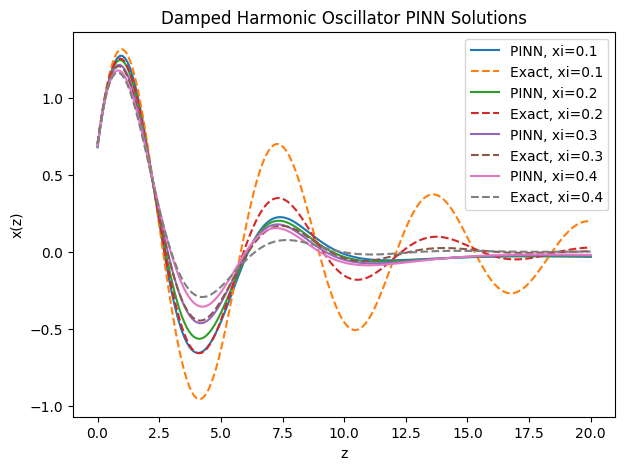

In [15]:
import numpy as np

def true_solution(z, xi, x0=0.7, v0=1.2):
    # xi < 1 => underdamped solution
    xi_ = xi.item() if isinstance(xi, torch.Tensor) else xi
    omega_d = np.sqrt(1 - xi_**2)
    A = x0
    B = (v0 + xi_*x0)/omega_d
    return np.exp(-xi_*z)*(A*np.cos(omega_d*z) + B*np.sin(omega_d*z))

# Evaluate & plot
net.eval()

z_plot = torch.linspace(0, 20, 200).view(-1,1)

fig = plt.figure(figsize=(7,5))

test_xi_list = [0.1, 0.2, 0.3, 0.4]  # a few sample damping values
for xi_test in test_xi_list:
    xi_tensor = torch.full_like(z_plot, xi_test)
    with torch.no_grad():
        x_pred = net(z_plot, xi_tensor).cpu().numpy().flatten()
    
    z_np = z_plot.cpu().numpy().flatten()
    # Plot PINN solution
    plt.plot(z_np, x_pred, label=f'PINN, xi={xi_test}')
    
    # Plot true solution (if underdamped)
    if xi_test < 1.0:
        x_true = [true_solution(z, xi_test) for z in z_np]
        plt.plot(z_np, x_true, '--', label=f'Exact, xi={xi_test}')

plt.xlabel('z')
plt.ylabel('x(z)')
plt.title('Damped Harmonic Oscillator PINN Solutions')
plt.legend()
plt.show()
